# 04 - Customer Analysis
Cross-checks `sql/03_customer_analysis.sql` in Python and builds an RFM (Recency / Frequency / Monetary) customer segmentation.

A "customer" here is `customer_unique_id` (the real person), not `customer_id` (a per-order key) - see notebook 01.

In [1]:
from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib.ticker as mticker, seaborn as sns
sns.set_theme(style="whitegrid", context="notebook"); pd.set_option("display.width", 160)
ROOT = Path("..").resolve(); SQL = ROOT / "reports" / "sql_results"
def brl(x, pos=None): return f"R${x/1000:,.0f}k" if abs(x) >= 1000 else f"R${x:,.0f}"

k = pd.read_csv(SQL / "03_customer_analysis__customer_kpis.csv").iloc[0]
print(f"Unique customers: {k.unique_customers:,.0f}  |  Repeat customers: {k.repeat_customers:,.0f} ({k.repeat_purchase_rate_pct:.2f}%)")
print(f"Avg spend: R$ {k.avg_spend_brl:.2f}  |  Median spend: R$ {k.median_spend_brl:.2f}  |  Revenue from repeat customers: {k.revenue_share_from_repeat_pct:.2f}%")

Unique customers: 94,983  |  Repeat customers: 2,887 (3.04%)
Avg spend: R$ 142.07  |  Median spend: R$ 89.89  |  Revenue from repeat customers: 5.56%


## Q1. What share of customers ever come back?

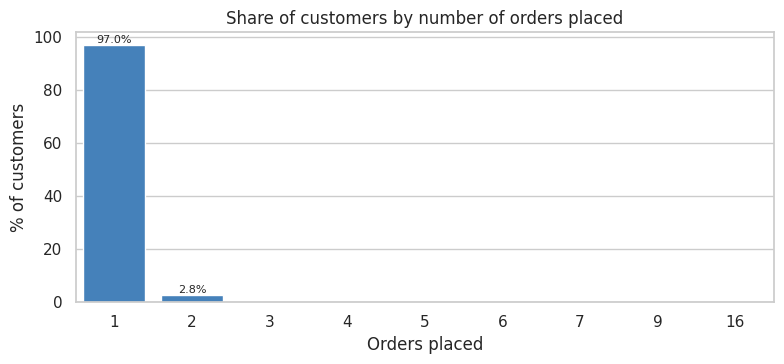

In [2]:
opc = pd.read_csv(SQL / "03_customer_analysis__orders_per_customer.csv")
fig, ax = plt.subplots(figsize=(8, 3.8))
sns.barplot(data=opc, x="orders_placed", y="pct_of_customers", color="#3182ce", ax=ax)
ax.set_title("Share of customers by number of orders placed"); ax.set_xlabel("Orders placed"); ax.set_ylabel("% of customers")
for p in ax.patches:
    h = p.get_height()
    if h > 0.3: ax.annotate(f"{h:.1f}%", (p.get_x()+p.get_width()/2, h), ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.savefig(ROOT/"reports"/"figures"/"orders_per_customer.png", dpi=110); plt.show()

**Finding:** only about 3% of customers place a second order; ~97% are one-time buyers. This is a known, structural feature of the Olist marketplace (customers buy from many small merchants, not a single repeat storefront) and not a data-quality issue - it was verified against SQL. **Implication:** growth depends mainly on acquiring new customers, not repeat purchase frequency; retention programs will move a much smaller lever here than in a typical single-brand retailer.

## Q2. How concentrated is revenue across customers?

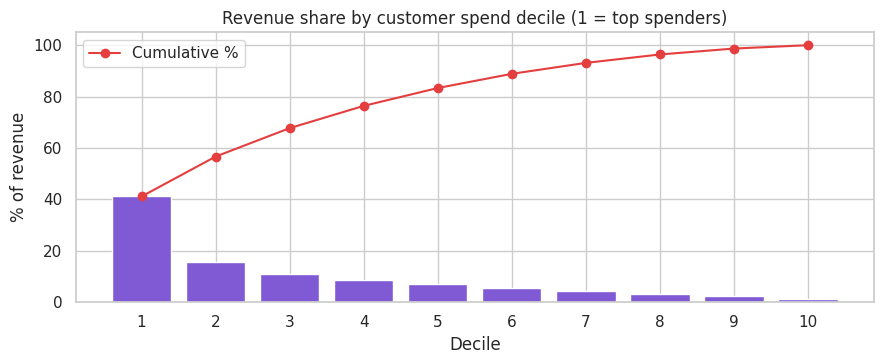

Top 10% of customers by spend = 41.1% of revenue; top 30% = 67.7%


In [3]:
dec = pd.read_csv(SQL / "03_customer_analysis__spend_deciles.csv")
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(dec.decile.astype(str), dec.revenue_share_pct, color="#805ad5")
ax.plot(dec.decile.astype(str), dec.cumulative_share_pct, color="#e53e3e", marker="o", label="Cumulative %")
ax.set_title("Revenue share by customer spend decile (1 = top spenders)"); ax.set_xlabel("Decile"); ax.set_ylabel("% of revenue"); ax.legend()
plt.tight_layout(); plt.savefig(ROOT/"reports"/"figures"/"spend_deciles.png", dpi=110); plt.show()
print(f"Top 10% of customers by spend = {dec.iloc[0].cumulative_share_pct:.1f}% of revenue; top 30% = {dec.iloc[2].cumulative_share_pct:.1f}%")

**Finding:** the top spending decile alone drives roughly a quarter of revenue. **Implication:** even without repeat purchasing, high-value single orders matter - discovering what drives a large first order (category, price point) is a lever worth investigating alongside acquisition.

## Q3. RFM customer segmentation
Methodology: for each customer, Recency = days since last valid order (snapshot = day after the last order date in the data), Frequency = number of valid orders, Monetary = total product spend. Because 97% of customers have Frequency = 1 (see Q1), classic 5x5x5 RFM quintiles would put almost everyone in the same frequency bucket and produce meaningless segments. Instead we use business-readable rules that combine frequency, recency and spend (thresholds and the segment SQL are in `database/transformations/01_views.sql`, view `vw_customer_rfm`):

| Segment | Rule |
|---|---|
| Champions | 2+ orders, last order within 180 days |
| Loyal Customers | 2+ orders, last order within 365 days |
| At-Risk Customers | 2+ orders but inactive > 365 days, OR a high-spend (>= R$155, the 75th percentile) one-time buyer who has gone quiet |
| Potential Loyalists | Recent first-time buyer (within 180 days) - could still return |
| Low-Engagement Customers | Everyone else: older, lower-spend, one-time buyers |

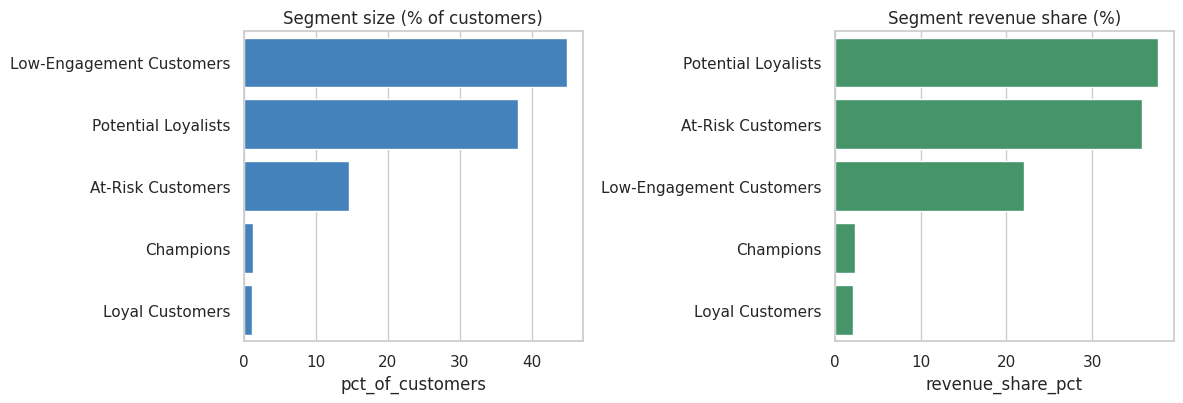

,segment,customers,pct_of_customers,avg_frequency,avg_monetary_brl,revenue_share_pct
0,Potential Loyalists,36108,38.02,1.00,140.63,37.63
1,At-Risk Customers,13917,14.65,1.04,346.45,35.73
2,Low-Engagement Customers,42621,44.87,1.00,69.85,22.06
3,Champions,1213,1.28,2.15,268.89,2.42
4,Loyal Customers,1124,1.18,2.09,259.48,2.16


In [4]:
seg = pd.read_csv(SQL / "08_advanced_analysis__rfm_segment_summary.csv")
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
order = seg.sort_values("customers", ascending=False)
sns.barplot(data=order, y="segment", x="pct_of_customers", ax=ax[0], color="#3182ce"); ax[0].set_title("Segment size (% of customers)"); ax[0].set_ylabel("")
order2 = seg.sort_values("revenue_share_pct", ascending=False)
sns.barplot(data=order2, y="segment", x="revenue_share_pct", ax=ax[1], color="#38a169"); ax[1].set_title("Segment revenue share (%)"); ax[1].set_ylabel("")
plt.tight_layout(); plt.savefig(ROOT/"reports"/"figures"/"rfm_segments.png", dpi=110); plt.show()
seg[["segment","customers","pct_of_customers","avg_frequency","avg_monetary_brl","revenue_share_pct"]]

**Finding:** 'Potential Loyalists' (recent first-timers) are 38% of customers and 38% of revenue - the single biggest opportunity pool, since whether they return is still undecided. 'Champions' and 'Loyal Customers' combined are barely 2.5% of customers, reflecting the low repeat rate. 'At-Risk Customers' (older buyers, some high spend, now inactive) hold 36% of revenue despite being only 15% of customers, because that group includes high one-time spenders. **Implication:** a win-back campaign aimed at 'At-Risk' high spenders, and an onboarding/second-purchase nudge for 'Potential Loyalists', are the two highest-leverage retention moves.

## Q4. Which customer states are most valuable?

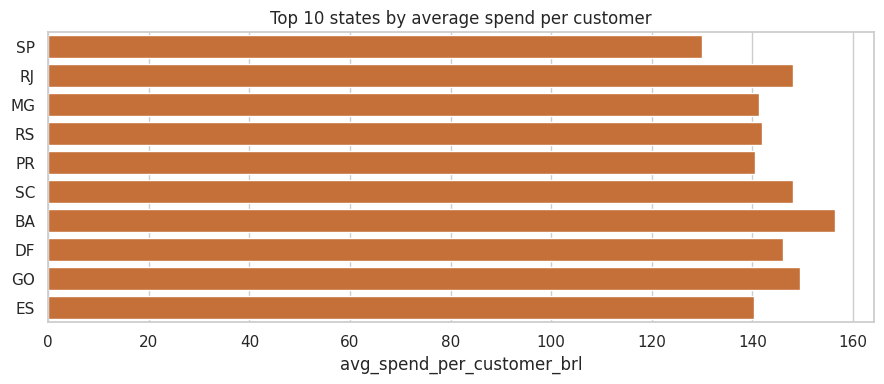

In [5]:
cv = pd.read_csv(SQL / "03_customer_analysis__customer_value_by_state.csv").head(10)
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=cv, y="state", x="avg_spend_per_customer_brl", color="#dd6b20", ax=ax)
ax.set_title("Top 10 states by average spend per customer"); ax.set_ylabel("")
plt.tight_layout(); plt.savefig(ROOT/"reports"/"figures"/"customer_value_by_state.png", dpi=110); plt.show()

**Finding:** average spend per customer varies by state more than revenue concentration alone would suggest - some lower-volume states have higher-value customers. **Implication:** state-level marketing spend should weigh average customer value, not just order volume.